<a href="https://colab.research.google.com/github/Mogacles/Codigos_Escuela/blob/main/D201_Algoritmos_y_Estructuras_de_Datos/Practica_1_2/Practica_1_2_MoralesJos%C3%A9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 1.2: Implementación y Análisis de Algoritmos de Ordenamiento Simple
## 1. Actividades

In [62]:
# Bibliotecas usadas
using Pkg
Pkg.add("DataFrames")
Pkg.add("Plots")
Pkg.add("Random")

using DataFrames
using Plots
using Random

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


### 1.1. Parte 1: Insertion Sort

In [63]:
function insertion_sort!(A)
  n = length(A) # Obtiene el tamano del arreglo

  # Bucle principal : avanza desde el segundo elemento hasta el final
  for j in 2:n
    key = A[j]
    i = j - 1

    # --- CODIGO DEL ALUMNO ---
    # Implementar el bucle while que desplaza los elementos
    # mayores que ’key ’ hacia la derecha .
    # Recuerde : en Julia los indices inician en 1.

    while i>=1 && A[i] > key
      A[i+1] = A[i]
      i -= 1
    end

    A[i + 1] = key
  end
  return A
end

insertion_sort! (generic function with 1 method)

### 1.2. Parte 2: Experimentación y Medición de Tiempo

In [64]:
# Definir tamano de prueba
N = [100, 1000, 5000, 10000]
# Vector para almacenar los tiempos de ejecución
tiempos = Float64[]
tiempos_big_omega = Float64[]
tiempos_big_o = Float64[]


# Prueba con una cantidad baja para evitar tiempos de ejecución muy largos
insertion_sort!(rand(10))

# Calcular los tiempos de ejecución para cada N
for n in N
    data_insertion = rand(n)
    time_ins = @elapsed insertion_sort!(data_insertion)
    push!(tiempos, time_ins)

    tiempo_omega = @elapsed insertion_sort!(collect(1:n))
    push!(tiempos_big_omega, tiempo_omega)

    tiempo_o = @elapsed insertion_sort!(collect(n:-1:1))
    push!(tiempos_big_o, tiempo_o)
end

#### 1.2.1 Tabla de comparacion de tiempos vs tamaño de entrada\

In [65]:
# 1.2.1 Tabla comparativa de tiempos vs tamaño de entreada
df = DataFrame(
  Entrada_N = N,
  Big_O = tiempos_big_o,
  Tiempo_de_ejecusión = tiempos,
  Big_Omega = tiempos_big_omega
)

display(df)

Row,Entrada_N,Big_O,Tiempo_de_ejecusión,Big_Omega
,Int64,Float64,Float64,Float64
1,100,1.4568e-5,8.907e-6,0.0249663
2,1000,0.000399175,0.000295757,6.215e-6
3,5000,0.00945859,0.00713547,2.3489e-5
4,10000,0.0377753,0.0289073,4.9148e-5


#### 1.2.2 Gráfica de comparacion de tiempos vs tamaño de entrada

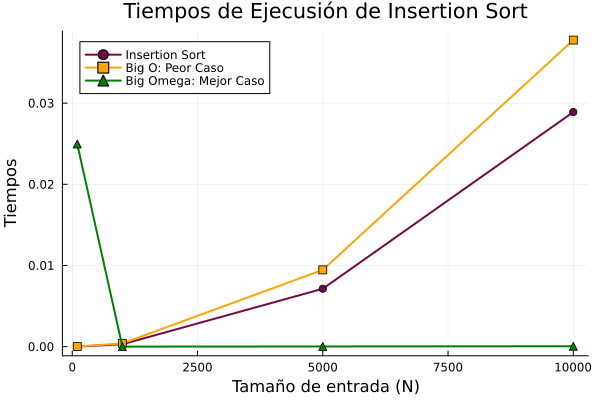

print device already activated


In [66]:
# 1.2.2 Gráficas de Tiempos vs N
p1 = plot(N, tiempos,
    label = "Insertion Sort",
    markershape = :circle,
    lw = 2,
    color = "#750946",
    legend = :topleft)
plot!(N, tiempos_big_o,
    label = "Big O: Peor Caso",
    markershape = :square,
    lw = 2,
    color = :orange)
plot!(N, tiempos_big_omega,
    label = "Big Omega: Mejor Caso",
    markershape = :utriangle,
    lw = 2,
    color = :green)

title!("Tiempos de Ejecusión de Insertion Sort")
xlabel!("Tamaño de entrada (N)")
ylabel!("Tiempos")